#  Notebook 1 — Data Preparation (YOLOv8)
**Steps:**
1. Install YOLOv8
2. Inspect dataset structure
3. Validate & clean YOLO labels
4. Fix `data.yaml` paths
5. Class distribution analysis

In [2]:
# ============================================================
#  CONFIG
# ============================================================
DATASET_BASE = "dataset"   #  root folder 

CLASSES = [          
    "traffic light", "traffic sign", "car", "person", "bus",
    "truck", "rider", "bike", "motor", "train", "banner", "tuktuk"
]
VALID_CLASS_IDS = set(range(len(CLASSES)))

SPLITS = {
    "train": f"{DATASET_BASE}/train/train",
    "val"  : f"{DATASET_BASE}/val/val",
    "test" : f"{DATASET_BASE}/test/test",
}

DATA_YAML = "data.yaml"  

print(f"Classes ({len(CLASSES)}): {CLASSES}")

Classes (12): ['traffic light', 'traffic sign', 'car', 'person', 'bus', 'truck', 'rider', 'bike', 'motor', 'train', 'banner', 'tuktuk']


## Step 1 — Install YOLOv8

In [3]:
# !pip install ultralytics -q
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

Ultralytics version: 8.4.30


## Step 2 — Inspect Dataset Structure

In [4]:
import os

print(f"{'Split':<8} {'Images':>8} {'Labels':>8}")
print("-" * 28)
for split, path in SPLITS.items():
    img_dir = os.path.join(path, "images")
    lbl_dir = os.path.join(path, "labels")
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    match = "" if imgs == lbls else "  mismatch!"
    print(f"{split:<8} {imgs:>8,} {lbls:>8,}  {match}")

# Peek at one label
sample_lbl_dir = os.path.join(SPLITS["train"], "labels")
sample_lbl = os.listdir(sample_lbl_dir)[0]
print(f"\nSample label ({sample_lbl}):")
with open(os.path.join(sample_lbl_dir, sample_lbl)) as f:
    print(f.read()[:200])

Split      Images   Labels
----------------------------
train      48,329   48,329  
val         6,278    6,278  
test        5,805    5,805  

Sample label (-5292-67-95-_Moment-10-_jpg.rf.956075bd58efbf17606e35e9573cb65f.txt):
4 0.49296875 0.48671875 0.665625 0.73046875
2 0.9125 0.478125 0.13671875 0.16328125


## Step 3 — Validate & Clean YOLO Labels

In [5]:
from pathlib import Path

DRY_RUN = True  #  set False to actually delete bad files

def is_valid_label(label_path, valid_classes):
    try:
        with open(label_path) as f:
            for i, line in enumerate(f, 1):
                parts = line.strip().split()
                if not parts: continue
                if len(parts) != 5:
                    return False, f"line {i}: need 5 values, got {len(parts)}"
                if int(parts[0]) not in valid_classes:
                    return False, f"line {i}: invalid class {parts[0]}"
                coords = list(map(float, parts[1:]))
                if any(not (0.0 <= x <= 1.0) for x in coords):
                    return False, f"line {i}: coords out of [0,1]"
        return True, "ok"
    except Exception as e:
        return False, str(e)

print(f"{'DRY RUN' if DRY_RUN else '  LIVE — deleting files!'}\n")
print(f"{'Split':<8} {'Bad Labels':>12} {'Removed Imgs':>14}")
print("-" * 38)

for split, path in SPLITS.items():
    img_dir = Path(os.path.join(path, "images"))
    lbl_dir = Path(os.path.join(path, "labels"))
    bad = removed = 0
    for lbl in lbl_dir.glob("*.txt"):
        valid, _ = is_valid_label(lbl, VALID_CLASS_IDS)
        if not valid:
            bad += 1
            for ext in [".jpg", ".jpeg", ".png"]:
                img = img_dir / (lbl.stem + ext)
                if img.exists():
                    if not DRY_RUN: img.unlink()
                    removed += 1; break
            if not DRY_RUN: lbl.unlink()
    print(f"{split:<8} {bad:>12,} {removed:>14,}")

if DRY_RUN:
    print("\n Set DRY_RUN=False to delete invalid files")

DRY RUN

Split      Bad Labels   Removed Imgs
--------------------------------------
train             974            974
val               153            153
test              128            128

 Set DRY_RUN=False to delete invalid files


## Step 4 — Fix data.yaml for Local Paths

In [ ]:
import yaml, os

# Read existing yaml
with open(DATA_YAML) as f:
    data = yaml.safe_load(f)

print("Current data.yaml:")
print(yaml.dump(data))

# Fix paths to absolute local paths
abs_base = os.path.abspath(DATASET_BASE)
data["train"] = os.path.join(abs_base, "train", "train", "images")
data["val"]   = os.path.join(abs_base, "val",   "val",   "images")
data["test"]  = os.path.join(abs_base, "test",  "test",  "images")
data["nc"]    = len(CLASSES)
data["names"] = CLASSES

# Save fixed yaml
FIXED_YAML = "data_local.yaml"  
with open(FIXED_YAML, "w") as f:
    yaml.dump(data, f, default_flow_style=False)

print(f"\n Fixed yaml saved to: {FIXED_YAML}")
print(yaml.dump(data))

Current data.yaml:
names:
- traffic light
- traffic sign
- car
- person
- bus
- truck
- rider
- bike
- motor
- train
- banner
- tuktuk
nc: 12
test: /kaggle/input/object-detection-for-autonomous-cars-egypt/test/test/images
train: /kaggle/input/object-detection-for-autonomous-cars-egypt/train/train/images
val: /kaggle/input/object-detection-for-autonomous-cars-egypt/val/val/images


 Fixed yaml saved to: data_local.yaml
names:
- traffic light
- traffic sign
- car
- person
- bus
- truck
- rider
- bike
- motor
- train
- banner
- tuktuk
nc: 12
test: c:\Users\hp\Desktop\proj2\dataset\test\test\images
train: c:\Users\hp\Desktop\proj2\dataset\train\train\images
val: c:\Users\hp\Desktop\proj2\dataset\val\val\images



## Step 5 — Class Distribution Analysis

Class              Count       %    Imbalance
----------------------------------------------
traffic light     11,975     4.2%       10.3x*
traffic sign      21,928     7.7%        5.6x*
car              123,542    43.3%        1.0x
person            31,735    11.1%        3.9x
bus               11,497     4.0%       10.7x*
truck             13,577     4.8%        9.1x*
rider             10,913     3.8%       11.3x*
bike               5,541     1.9%       22.3x*
motor             13,164     4.6%        9.4x*
train              7,187     2.5%       17.2x*
banner            28,879    10.1%        4.3x
tuktuk             5,564     1.9%       22.2x*


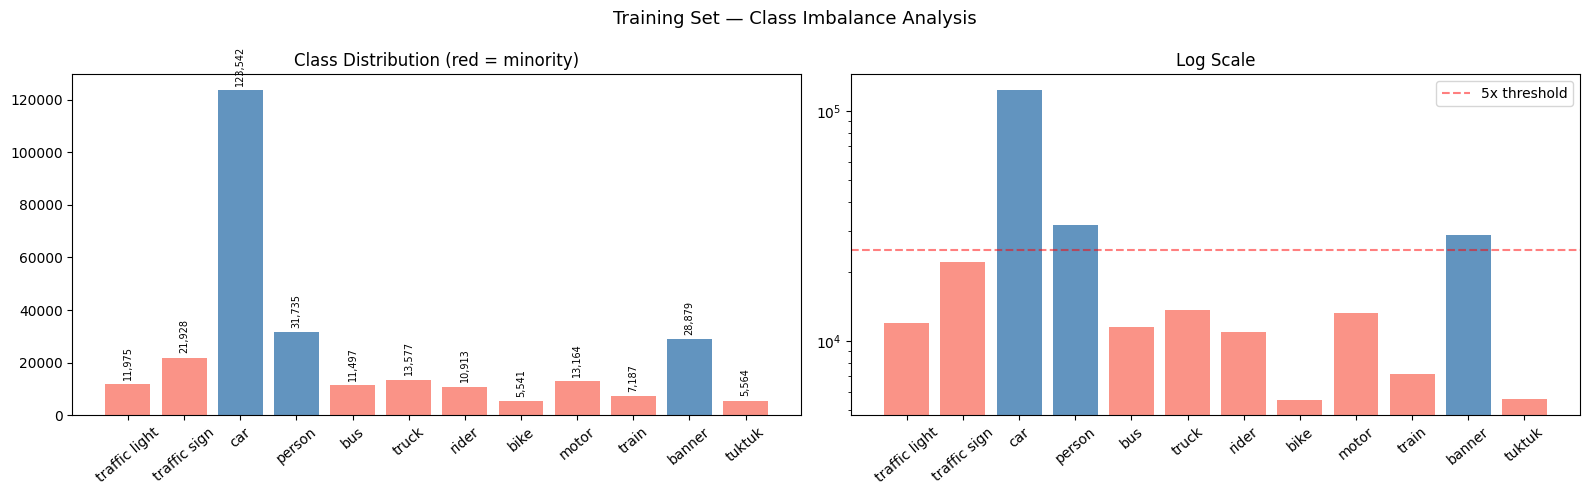

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

lbl_dir = os.path.join(SPLITS["train"], "labels")
counts = Counter()

for lbl_file in os.listdir(lbl_dir):
    with open(os.path.join(lbl_dir, lbl_file)) as f:
        for line in f:
            parts = line.strip().split()
            if parts: counts[int(parts[0])] += 1

class_names  = [CLASSES[i] for i in sorted(counts)]
class_counts = [counts[i]  for i in sorted(counts)]
max_count    = max(class_counts)

print(f"{'Class':<15} {'Count':>8} {'%':>7} {'Imbalance':>12}")
print("-" * 46)
for name, count in zip(class_names, class_counts):
    ratio = max_count / max(count, 1)
    flag  = "*" if ratio > 5 else ""
    print(f"{name:<15} {count:>8,} {count/sum(class_counts)*100:>7.1f}% {ratio:>10.1f}x{flag}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['salmon' if max_count/max(c,1) > 5 else 'steelblue' for c in class_counts]

bars = axes[0].bar(class_names, class_counts, color=colors, alpha=0.85)
axes[0].bar_label(bars, labels=[f'{c:,}' for c in class_counts], fontsize=7, rotation=90, padding=3)
axes[0].set_title("Class Distribution (red = minority)"); axes[0].tick_params(axis='x', rotation=40)

axes[1].bar(class_names, class_counts, color=colors, alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title("Log Scale"); axes[1].tick_params(axis='x', rotation=40)
axes[1].axhline(max_count/5, color='red', linestyle='--', alpha=0.5, label='5x threshold')
axes[1].legend()

plt.suptitle("Training Set — Class Imbalance Analysis", fontsize=13)
plt.tight_layout()
# plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()